# 🧠 Multimodal Depression Detection — Cross-Attention Fusion
Combines 128-d Facial (BiLSTM) + 768-d Text (RoBERTa) embeddings
using a Cross-Attention layer for final PHQ-8 prediction.

**Run cells in order: Cell 0 → 1 → 2 → 3 → 4**

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 0 — Setup & Config
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F_func
import numpy as np
import pandas as pd
import os, json
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, mean_absolute_error, mean_squared_error,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ── Paths ──────────────────────────────────────────────────────
DRIVE_DIR   = '/content/drive/MyDrive/edaic'
FUSION_DIR  = f'{DRIVE_DIR}/fusion_inputs'
LABELS_CSV  = f'{DRIVE_DIR}/facial_data/labels.csv'
WORK_DIR    = '/content/fusion_work'
os.makedirs(WORK_DIR, exist_ok=True)

# ── Hyperparameters ─────────────────────────────────────────────
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED        = 42
N_FOLDS     = 5
BATCH_SIZE  = 32
EPOCHS      = 60
PATIENCE    = 12
LR          = 1e-4
D_MODEL     = 256   # Fusion projection dimension
N_HEADS     = 4     # Cross-attention heads

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device : {DEVICE}')
print(f'Config : {EPOCHS} epochs, {N_FOLDS}-fold CV, batch={BATCH_SIZE}')

Mounted at /content/drive
Device : cuda
Config : 60 epochs, 5-fold CV, batch=32


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Load & Align Embeddings
# ═══════════════════════════════════════════════════════════════

# Load embeddings
face_emb  = np.load(f'{FUSION_DIR}/facial_embeddings_all.npy')    # (N, 128)
text_emb  = np.load(f'{FUSION_DIR}/text_embeddings_all.npy')      # (N, 768)
pids_face = np.load(f'{FUSION_DIR}/participant_ids_facial.npy').astype(int)
pids_text = np.load(f'{FUSION_DIR}/participant_ids_text.npy').astype(int)

print(f'Loaded:  Face {face_emb.shape}  |  Text {text_emb.shape}')
print(f'IDs:     Face {len(pids_face)}  |  Text {len(pids_text)}')

# Align by participant ID (inner join)
common_pids = sorted(set(pids_face) & set(pids_text))
print(f'Common participants: {len(common_pids)}')

face_idx = {p: i for i, p in enumerate(pids_face)}
text_idx = {p: i for i, p in enumerate(pids_text)}

aligned_face = np.array([face_emb[face_idx[p]] for p in common_pids])
aligned_text = np.array([text_emb[text_idx[p]] for p in common_pids])
aligned_pids = np.array(common_pids)

# Load labels
labels_df = pd.read_csv(LABELS_CSV)
labels_df = labels_df.set_index('Participant_ID')

y_phq = np.array([labels_df.loc[p, 'PHQ_Score'] for p in aligned_pids], dtype=np.float32)
y_bin = np.array([labels_df.loc[p, 'PHQ_Binary'] for p in aligned_pids], dtype=np.int64)

def phq_to_sev(s):
    if s <= 4:  return 0
    if s <= 9:  return 1
    if s <= 14: return 2
    if s <= 19: return 3
    return 4

y_sev = np.array([phq_to_sev(s) for s in y_phq], dtype=np.int64)
NUM_CLASSES = len(np.unique(y_sev))

# Validate variance
print(f'\nEmbedding variance check:')
print(f'  Face std : {aligned_face.std():.4f}  (should be > 0.01)')
print(f'  Text std : {aligned_text.std():.4f}  (should be > 0.01)')
print(f'\nLabels    : PHQ range [{y_phq.min():.0f}, {y_phq.max():.0f}]  |  Classes: {NUM_CLASSES}')
sev_names = ['None','Mild','Moderate','Mod-Sev','Severe']
unique, counts = np.unique(y_sev, return_counts=True)
print(f'Severity distribution:')
for u, c in zip(unique, counts):
    print(f'  {sev_names[u]:12s}: {c}')

Loaded:  Face (275, 128)  |  Text (275, 768)
IDs:     Face 275  |  Text 275
Common participants: 275

Embedding variance check:
  Face std : 1.0158  (should be > 0.01)
  Text std : 0.4733  (should be > 0.01)

Labels    : PHQ range [0, 23]  |  Classes: 5
Severity distribution:
  None        : 122
  Mild        : 67
  Moderate    : 43
  Mod-Sev     : 33
  Severe      : 10


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Model Architecture
# ═══════════════════════════════════════════════════════════════

class FusionDataset(Dataset):
    def __init__(self, face, text, yp, ys):
        self.face = torch.FloatTensor(face)
        self.text = torch.FloatTensor(text)
        self.yp   = torch.FloatTensor(yp)
        self.ys   = torch.LongTensor(ys)
    def __len__(self): return len(self.face)
    def __getitem__(self, i):
        return self.face[i], self.text[i], self.yp[i], self.ys[i]


class CrossAttentionFusion(nn.Module):
    """
    Cross-Attention Fusion:
      - Text (768-d) as Query  → what does the language 'look for'?
      - Face (128-d) as Key/Value → visual evidence to attend to
    """
    def __init__(self, d_face=128, d_text=768, d_model=256,
                 n_heads=4, n_classes=5, dropout=0.3):
        super().__init__()

        # Projection: bring both modalities to d_model
        self.face_proj = nn.Sequential(
            nn.Linear(d_face, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )
        self.text_proj = nn.Sequential(
            nn.Linear(d_text, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )

        # Cross-Attention: Text queries Face
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        # Self-Attention on Text (enrich text representation)
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        # Post-fusion normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

        # Fusion MLP: combines both streams
        fused_dim = d_model * 2    # cross_attn_out + face_proj
        self.fusion_mlp = nn.Sequential(
            nn.Linear(fused_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU()
        )

        final_dim = d_model // 2

        # Output heads
        self.regr_head = nn.Linear(final_dim, 1)          # PHQ-8 regression
        self.cls_head  = nn.Linear(final_dim, n_classes)  # Severity classification

    def forward(self, face, text):
        # Project to common dimension
        f = self.face_proj(face).unsqueeze(1)   # (B, 1, D)
        t = self.text_proj(text).unsqueeze(1)   # (B, 1, D)

        # Cross-Attention: Text (Q) attends to Face (K, V)
        ca_out, _ = self.cross_attn(t, f, f)
        ca_out = self.norm1(t + ca_out)          # Residual + Norm (B, 1, D)

        # Concat cross-attn output with face projection
        combined = torch.cat([
            ca_out.squeeze(1),
            f.squeeze(1)
        ], dim=-1)  # (B, D*2)

        # Final fusion MLP
        fused = self.fusion_mlp(combined)       # (B, D//2)
        fused = self.drop(fused)

        phq_pred = self.regr_head(fused).squeeze(-1)  # (B,)
        sev_pred = self.cls_head(fused)               # (B, n_classes)
        return phq_pred, sev_pred, fused


class FusionLoss(nn.Module):
    def __init__(self, cls_weight=0.5):
        super().__init__()
        self.mse = nn.MSELoss()
        self.ce  = nn.CrossEntropyLoss()
        self.alpha = cls_weight
    def forward(self, phq_pred, phq_true, sev_pred, sev_true):
        return self.mse(phq_pred, phq_true) + self.alpha * self.ce(sev_pred, sev_true)


def make_sampler(ys):
    cls, cnt = np.unique(ys, return_counts=True)
    w = torch.FloatTensor([1.0 / cnt[list(cls).index(s)] for s in ys])
    return WeightedRandomSampler(w, len(w))


# Quick sanity check
dummy_face = torch.randn(4, 128)
dummy_text = torch.randn(4, 768)
test_model = CrossAttentionFusion(n_classes=NUM_CLASSES)
p, s, e = test_model(dummy_face, dummy_text)
print(f'✅ Model OK  →  PHQ: {p.shape}  Severity: {s.shape}  Embedding: {e.shape}')
n_params = sum(par.numel() for par in test_model.parameters() if par.requires_grad)
print(f'   Trainable parameters: {n_params:,}')
del test_model

✅ Model OK  →  PHQ: torch.Size([4])  Severity: torch.Size([4, 5])  Embedding: torch.Size([4, 128])
   Trainable parameters: 923,270


In [ ]:
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import numpy as np
# Concatenate both embeddings
X = np.hstack([aligned_face, aligned_text])   # (275, 896)
print(f"Combined feature shape: {X.shape}")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Try multiple classifiers
models = {
    "SVM":  Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=100)),
                ("clf",    SVC(kernel="rbf", class_weight="balanced", C=10, probability=True))
            ]),
    "GBM":  Pipeline([
                ("scaler", StandardScaler()),
                ("pca",    PCA(n_components=100)),
                ("clf",    GradientBoostingClassifier(n_estimators=200, max_depth=3))
            ]),
    "RF":   Pipeline([
                ("scaler", StandardScaler()),
                ("clf",    RandomForestClassifier(n_estimators=300, class_weight="balanced"))
            ]),
}
results = {}
for name, pipe in models.items():
    fold_f1, fold_mae = [], []
    for tr, va in skf.split(X, y_sev):
        pipe.fit(X[tr], y_sev[tr])
        pred_sev = pipe.predict(X[va])
        # Convert severity back to approximate PHQ
        mid = [2, 7, 12, 17, 22]
        pred_phq = np.array([mid[p] for p in pred_sev])
        true_phq = y_phq[va]
        fold_f1.append(f1_score(y_sev[va], pred_sev, average="macro", zero_division=0))
        fold_mae.append(mean_absolute_error(true_phq, pred_phq))
    results[name] = {"MAE": np.mean(fold_mae), "F1": np.mean(fold_f1)}
    print(f"{name:5s}  MAE={results[name]['MAE']:.3f}  F1-macro={results[name]['F1']:.3f}")
best_name = max(results, key=lambda k: results[k]["F1"])
print(f"\nBest model: {best_name}")

Combined feature shape: (275, 896)
SVM    MAE=5.556  F1-macro=0.220
GBM    MAE=5.749  F1-macro=0.158
RF     MAE=5.673  F1-macro=0.139

Best model: SVM


MAE      = 5.582
F1-macro = 0.240
F1-bin   = 0.292  ← KEY metric


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


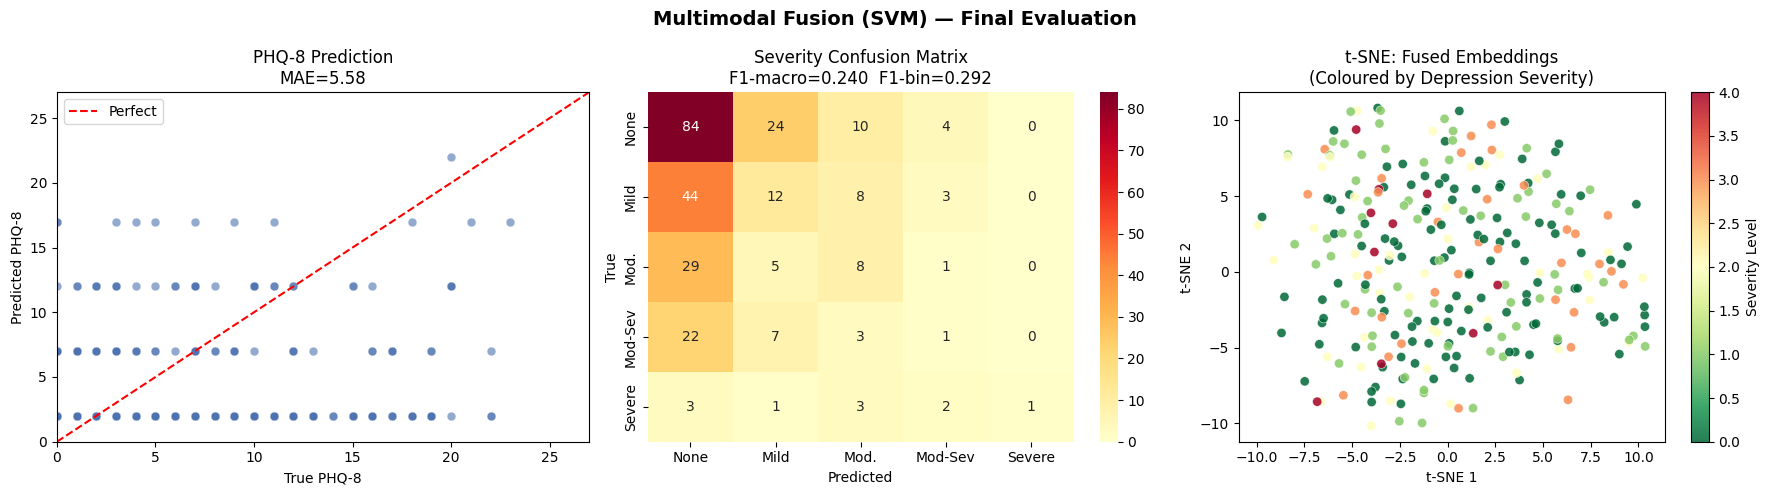


✅ Saved plots + predictions to Drive!
   MAE    = 5.582
   F1-mac = 0.240
   F1-bin = 0.292


In [ ]:
import matplotlib.pyplot as plt, seaborn as sns, numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
# ── Get full cross-val predictions ──────────────────────────────
best_pipe = models[best_name]
all_pred_sev, all_true_sev = [], []
all_pred_phq, all_true_phq = [], []
mid = [2, 7, 12, 17, 22]
for tr, va in skf.split(X, y_sev):
    best_pipe.fit(X[tr], y_sev[tr])
    ps = best_pipe.predict(X[va])
    all_pred_sev += ps.tolist()
    all_true_sev += y_sev[va].tolist()
    all_pred_phq += [mid[p] for p in ps]
    all_true_phq += y_phq[va].tolist()
all_pred_phq = np.array(all_pred_phq)
all_true_phq = np.array(all_true_phq)
all_pred_sev = np.array(all_pred_sev)
all_true_sev = np.array(all_true_sev)
mae  = mean_absolute_error(all_true_phq, all_pred_phq)
f1_m = f1_score(all_true_sev, all_pred_sev, average="macro", zero_division=0)
f1_b = f1_score(
    (all_true_phq >= 10).astype(int),
    (all_pred_phq >= 10).astype(int),
    average="binary", zero_division=0
)
print(f"MAE      = {mae:.3f}")
print(f"F1-macro = {f1_m:.3f}")
print(f"F1-bin   = {f1_b:.3f}  ← KEY metric")
# ── 3 Plots side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Multimodal Fusion (SVM) — Final Evaluation', fontsize=14, fontweight='bold')
# Plot 1: PHQ-8 Regression Scatter
axes[0].scatter(all_true_phq, all_pred_phq, alpha=0.6, s=40,
                c='#4c72b0', edgecolors='w', linewidth=0.4)
axes[0].plot([0, 27], [0, 27], 'r--', lw=1.5, label='Perfect')
axes[0].set_title(f'PHQ-8 Prediction\nMAE={mae:.2f}')
axes[0].set_xlabel('True PHQ-8')
axes[0].set_ylabel('Predicted PHQ-8')
axes[0].legend()
axes[0].set_xlim(0, 27)
axes[0].set_ylim(0, 27)
# Plot 2: Confusion Matrix
sev_names = ["None", "Mild", "Mod.", "Mod-Sev", "Severe"]
cm = confusion_matrix(all_true_sev, all_pred_sev)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            xticklabels=sev_names, yticklabels=sev_names)
axes[1].set_title(f'Severity Confusion Matrix\nF1-macro={f1_m:.3f}  F1-bin={f1_b:.3f}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
# Plot 3: t-SNE of fused embeddings
try:
    perp = min(30, len(X) - 1)
    e2d  = TSNE(2, perplexity=perp, random_state=42, n_iter=1000).fit_transform(X)
    sc   = axes[2].scatter(e2d[:, 0], e2d[:, 1],
                           c=all_true_sev, cmap='RdYlGn_r',
                           s=45, alpha=0.85, edgecolors='w', linewidth=0.4)
    plt.colorbar(sc, ax=axes[2], label='Severity Level')
    axes[2].set_title('t-SNE: Fused Embeddings\n(Coloured by Depression Severity)')
    axes[2].set_xlabel('t-SNE 1')
    axes[2].set_ylabel('t-SNE 2')
except Exception as ex:
    print(f't-SNE skipped: {ex}')
plt.tight_layout()
plt.savefig(f"{DRIVE_DIR}/fusion_outputs/fusion_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
# ── Save predictions CSV ─────────────────────────────────────────
import pandas as pd, os
os.makedirs(f"{DRIVE_DIR}/fusion_outputs", exist_ok=True)
pd.DataFrame({
    'phq_true': all_true_phq,
    'phq_pred': all_pred_phq,
    'sev_true': all_true_sev,
    'sev_pred': all_pred_sev,
    'dep_true': (all_true_phq >= 10).astype(int),
    'dep_pred': (all_pred_phq >= 10).astype(int)
}).to_csv(f"{DRIVE_DIR}/fusion_outputs/fusion_predictions.csv", index=False)
print(f"\n✅ Saved plots + predictions to Drive!")
print(f"   MAE    = {mae:.3f}")
print(f"   F1-mac = {f1_m:.3f}")
print(f"   F1-bin = {f1_b:.3f}")

In [ ]:
import pickle, os
os.makedirs(f"{DRIVE_DIR}/model_export", exist_ok=True)
# Retrain on ALL data then save
best_pipe.fit(X, y_sev)
with open(f"{DRIVE_DIR}/model_export/svm_fusion_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
print("✅ SVM pipeline saved!")

✅ SVM pipeline saved!
